In [4]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 2.1 MB/s eta 0:00:48
   ---------------------------------------- 0.5/100.2 MB 2.1 MB/s eta 0:00:48
   ---------------------------------------- 1.0/100.2 MB 1.2 MB/s eta 0:01:21
    --------------------------------------- 1.8/100.2 MB 1.7 MB/s eta 0:00:58
    --------------------------------------- 2.4/100.2 MB 2.0 MB/s eta 0:00:50
    --------------------------------------- 2.4/100.2 MB 2.0 MB/s eta 0:00:50
    --------------------------------------- 2.4/100.2 MB 2.0 MB/s eta 0:00:50
   - -------------------------------------- 2.6/100.2 MB 1.4 MB/s eta 0:01:10
   - -------------------------------------- 3.1/100.2 MB 1.5 MB/s eta 0:01:04
   - -------------------------------------- 3.7/100.2 MB 1.7 MB/s eta 0:00:59
   - -------------------------------------- 3.9/100.2 MB 1.7 MB/s eta 0:00:58



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# ============================================================
# MODEL 2 : HEAT MORTALITY / HEALTH RISK PREDICTION
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import GroupKFold
from sklearn.model_selection import cross_validate

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from catboost import CatBoostRegressor

import joblib

print("Libraries Loaded Successfully")

ModuleNotFoundError: No module named 'catboost'

In [2]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(r"E:/sih/master_district_year_dataset.csv")

print("Dataset Loaded Successfully")
print()

print("Shape :", df.shape)

display(df.head())

Dataset Loaded Successfully

Shape : (3531, 28)


,district,state,year,region_type,pop_below_15_pct,sex_ratio,electricity_access_pct,safe_water_pct,sanitation_pct,clean_fuel_pct,...,clim_wbgt_p90,clim_wbgt_max,clim_heatindex_mean,clim_pct_extreme_readings,clim_n_grid_points,heatstroke_deaths,heatwave_deaths_alt_source,has_weather_climatology,has_nfhs_demographics,mortality_label_granularity
0,Nicobars,Andaman and Nicobar Islands,2018,Union Teritory,22.98,973.31,97.9,98.81,83.45,56.93,...,36.854418,40.822963,33.330693,97.34,11.0,0.0,NaN,True,True,state_year_shared
1,Nicobars,Andaman and Nicobar Islands,2019,Union Teritory,22.98,973.31,97.9,98.81,83.45,56.93,...,36.854418,40.822963,33.330693,97.34,11.0,0.0,NaN,True,True,state_year_shared
2,Nicobars,Andaman and Nicobar Islands,2020,Union Teritory,22.98,973.31,97.9,98.81,83.45,56.93,...,36.854418,40.822963,33.330693,97.34,11.0,0.0,NaN,True,True,state_year_shared
3,Nicobars,Andaman and Nicobar Islands,2021,Union Teritory,22.98,973.31,97.9,98.81,83.45,56.93,...,36.854418,40.822963,33.330693,97.34,11.0,0.0,NaN,True,True,state_year_shared
4,Nicobars,Andaman and Nicobar Islands,2022,Union Teritory,22.98,973.31,97.9,98.81,83.45,56.93,...,36.854418,40.822963,33.330693,97.34,11.0,0.0,NaN,True,True,state_year_shared


In [5]:
# ============================================================
# DATASET INFORMATION
# ============================================================

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

print()

print("="*60)
print("Missing Values")
print("="*60)

display(df.isnull().sum())

print()

print("="*60)
print("Statistical Summary")
print("="*60)

display(df.describe())


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 3531 entries, 0 to 3530
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   district                     3531 non-null   str    
 1   state                        3531 non-null   str    
 2   year                         3531 non-null   int64  
 3   region_type                  3531 non-null   str    
 4   pop_below_15_pct             3531 non-null   float64
 5   sex_ratio                    3531 non-null   float64
 6   electricity_access_pct       3531 non-null   float64
 7   safe_water_pct               3531 non-null   float64
 8   sanitation_pct               3531 non-null   float64
 9   clean_fuel_pct               3531 non-null   float64
 10  health_insurance_pct         3531 non-null   float64
 11  women_literacy_pct           3531 non-null   float64
 12  women_underweight_pct        3531 non-null   float64
 13  women_ove

district                          0
state                             0
year                              0
region_type                       0
pop_below_15_pct                  0
sex_ratio                         0
electricity_access_pct            0
safe_water_pct                    0
sanitation_pct                    0
clean_fuel_pct                    0
health_insurance_pct              0
women_literacy_pct                0
women_underweight_pct             0
women_overweight_pct              0
women_anaemia_pct                 0
women_hypertension_pct            0
men_hypertension_pct              0
clim_wbgt_mean                  451
clim_wbgt_p90                   451
clim_wbgt_max                   451
clim_heatindex_mean             451
clim_pct_extreme_readings       451
clim_n_grid_points              451
heatstroke_deaths                 0
heatwave_deaths_alt_source     2066
has_weather_climatology           0
has_nfhs_demographics             0
mortality_label_granularity 


Statistical Summary


,year,pop_below_15_pct,sex_ratio,electricity_access_pct,safe_water_pct,sanitation_pct,clean_fuel_pct,health_insurance_pct,women_literacy_pct,women_underweight_pct,...,women_hypertension_pct,men_hypertension_pct,clim_wbgt_mean,clim_wbgt_p90,clim_wbgt_max,clim_heatindex_mean,clim_pct_extreme_readings,clim_n_grid_points,heatstroke_deaths,heatwave_deaths_alt_source
count,3531.000000,3531.000000,3531.000000,3531.000000,3531.000000,3531.000000,3531.000000,3531.000000,3531.000000,3531.000000,...,3531.000000,3531.000000,3080.000000,3080.000000,3080.000000,3080.000000,3080.000000,3080.000000,3531.000000,1465.000000
mean,2020.001699,26.360949,1020.752436,96.993223,93.731810,71.951025,54.061526,40.247924,74.321886,17.902889,...,21.407969,24.768003,35.851046,39.530125,43.555173,37.823406,91.433961,3.495130,37.460776,5.391809
std,1.414213,5.294880,73.347882,4.353362,8.712857,14.248345,24.160144,23.044956,12.239554,7.432278,...,5.210813,6.763154,4.427814,3.893646,3.702341,5.072636,20.257345,2.242227,49.156849,20.021148
min,2018.000000,15.980000,754.980000,68.350000,41.180000,29.240000,8.610000,1.150000,38.600000,1.170000,...,8.530000,10.020000,15.231385,22.175162,27.403895,23.491030,0.000000,1.000000,0.000000,0.000000
25%,2019.000000,22.505000,969.055000,96.390000,92.030000,62.020000,33.920000,20.380000,66.810000,12.670000,...,17.625000,19.825000,35.316444,39.277995,43.275139,36.272555,94.350000,2.000000,0.000000,0.000000
50%,2020.000000,25.360000,1013.260000,98.650000,96.980000,73.730000,50.420000,35.740000,75.070000,17.990000,...,21.010000,24.420000,37.070248,40.243214,44.813721,38.152440,97.610000,3.000000,15.000000,0.000000
75%,2021.000000,29.530000,1065.560000,99.515000,99.250000,83.320000,75.140000,60.020000,83.710000,23.090000,...,24.460000,28.980000,38.504042,41.936707,45.382407,41.472528,99.690000,5.000000,53.000000,2.000000
max,2022.000000,50.560000,1331.640000,100.000000,100.000000,99.850000,99.790000,97.790000,99.720000,43.580000,...,42.090000,49.610000,39.471743,42.716479,46.258081,51.896002,99.950000,11.000000,215.000000,121.000000


,Column,Missing,Percentage
heatwave_deaths_alt_source,heatwave_deaths_alt_source,2066,58.510337
clim_wbgt_max,clim_wbgt_max,451,12.772586
clim_wbgt_p90,clim_wbgt_p90,451,12.772586
clim_wbgt_mean,clim_wbgt_mean,451,12.772586
clim_n_grid_points,clim_n_grid_points,451,12.772586
clim_heatindex_mean,clim_heatindex_mean,451,12.772586
clim_pct_extreme_readings,clim_pct_extreme_readings,451,12.772586
pop_below_15_pct,pop_below_15_pct,0,0.000000
district,district,0,0.000000
state,state,0,0.000000


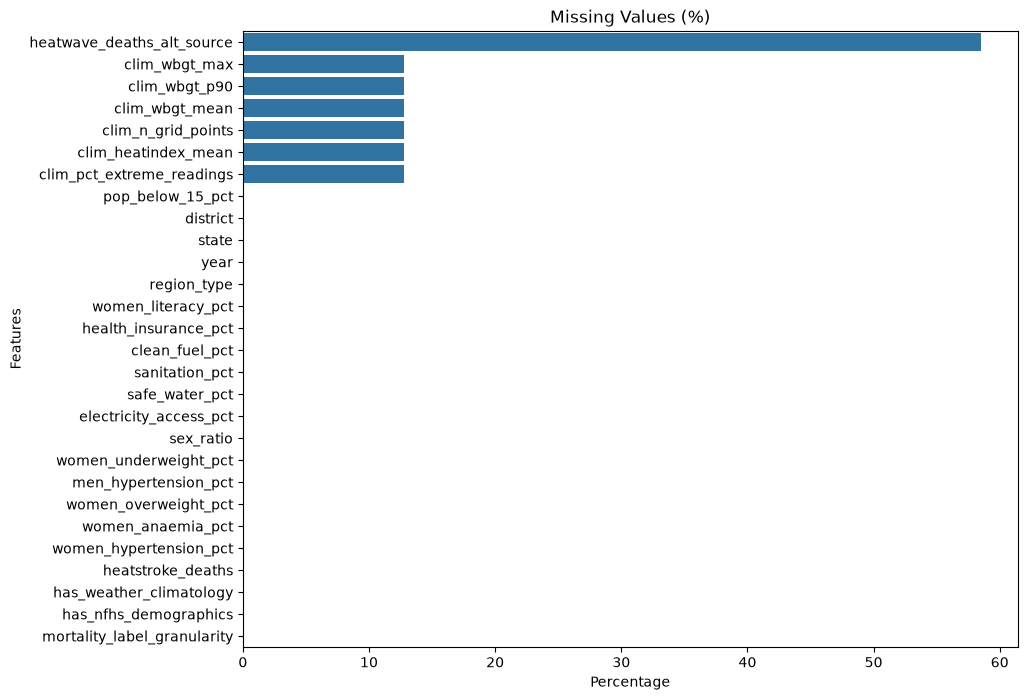

In [6]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

missing = pd.DataFrame({

    "Column": df.columns,
    "Missing": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100

})

missing = missing.sort_values(
    by="Percentage",
    ascending=False
)

display(missing)

plt.figure(figsize=(10,8))

sns.barplot(
    data=missing,
    y="Column",
    x="Percentage"
)

plt.title("Missing Values (%)")

plt.xlabel("Percentage")

plt.ylabel("Features")

plt.show()

In [7]:
# ============================================================
# DUPLICATE CHECK
# ============================================================

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [8]:
# ============================================================
# SELECT TARGET
# ============================================================

TARGET = "heatstroke_deaths"

print("Target Variable :", TARGET)

print("\nMissing Values in Target :", df[TARGET].isnull().sum())

Target Variable : heatstroke_deaths

Missing Values in Target : 0


In [9]:
# ============================================================
# REMOVE MISSING TARGET
# ============================================================

df = df.dropna(subset=[TARGET]).reset_index(drop=True)

print("Dataset Shape :", df.shape)

Dataset Shape : (3531, 28)


In [10]:
# ============================================================
# FEATURES AND TARGET
# ============================================================

y = df[TARGET]

X = df.drop(columns=[TARGET])

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (3531, 27)
Target Shape : (3531,)


In [11]:
# ============================================================
# CREATE GROUPS FOR GROUP K FOLD
# ============================================================

groups = (
    df["state"].astype(str)
    + "_"
    + df["year"].astype(str)
)

print(groups.head())

0    Andaman and Nicobar Islands_2018
1    Andaman and Nicobar Islands_2019
2    Andaman and Nicobar Islands_2020
3    Andaman and Nicobar Islands_2021
4    Andaman and Nicobar Islands_2022
dtype: str


In [12]:
# ============================================================
# REMOVE IDENTIFIER COLUMNS
# ============================================================

drop_cols = [
    "district",
    "state",
    "year",
    "mortality_label_granularity"
]

existing = [c for c in drop_cols if c in X.columns]

X = X.drop(columns=existing)

print("Remaining Features :", X.shape[1])

display(X.head())

Remaining Features : 23


,region_type,pop_below_15_pct,sex_ratio,electricity_access_pct,safe_water_pct,sanitation_pct,clean_fuel_pct,health_insurance_pct,women_literacy_pct,women_underweight_pct,...,men_hypertension_pct,clim_wbgt_mean,clim_wbgt_p90,clim_wbgt_max,clim_heatindex_mean,clim_pct_extreme_readings,clim_n_grid_points,heatwave_deaths_alt_source,has_weather_climatology,has_nfhs_demographics
0,Union Teritory,22.98,973.31,97.9,98.81,83.45,56.93,2.65,87.54,8.18,...,46.97,34.272106,36.854418,40.822963,33.330693,97.34,11.0,NaN,True,True
1,Union Teritory,22.98,973.31,97.9,98.81,83.45,56.93,2.65,87.54,8.18,...,46.97,34.272106,36.854418,40.822963,33.330693,97.34,11.0,NaN,True,True
2,Union Teritory,22.98,973.31,97.9,98.81,83.45,56.93,2.65,87.54,8.18,...,46.97,34.272106,36.854418,40.822963,33.330693,97.34,11.0,NaN,True,True
3,Union Teritory,22.98,973.31,97.9,98.81,83.45,56.93,2.65,87.54,8.18,...,46.97,34.272106,36.854418,40.822963,33.330693,97.34,11.0,NaN,True,True
4,Union Teritory,22.98,973.31,97.9,98.81,83.45,56.93,2.65,87.54,8.18,...,46.97,34.272106,36.854418,40.822963,33.330693,97.34,11.0,NaN,True,True


In [13]:
# ============================================================
# LABEL ENCODING
# ============================================================

label_encoders = {}

cat_cols = X.select_dtypes(include="object").columns

print("Categorical Columns")
print(cat_cols)

for col in cat_cols:

    le = LabelEncoder()

    X[col] = le.fit_transform(X[col].astype(str))

    label_encoders[col] = le

print("Encoding Completed")

Categorical Columns
Index(['region_type'], dtype='str')
Encoding Completed


In [14]:
# ============================================================
# IMPUTE MISSING VALUES
# ============================================================

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(

    imputer.fit_transform(X),

    columns=X.columns

)

print("Missing Values Remaining")

print(X.isnull().sum().sum())

Missing Values Remaining
0


In [15]:
# ============================================================
# DEFINE MODELS
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

print("Models Initialized Successfully!")

Models Initialized Successfully!


In [16]:
# ============================================================
# GROUP K-FOLD VALIDATION FUNCTION
# ============================================================

gkf = GroupKFold(n_splits=5)

def evaluate_model(model, X, y, groups):
    
    mae_scores = []
    rmse_scores = []
    r2_scores = []

    fold = 1

    for train_idx, test_idx in gkf.split(X, y, groups):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)

        print(f"Fold {fold}")
        print("MAE :", round(mae,2))
        print("RMSE:", round(rmse,2))
        print("R2  :", round(r2,3))
        print("-"*40)

        mae_scores.append(mae)
        rmse_scores.append(rmse)
        r2_scores.append(r2)

        fold += 1

    return {
        "MAE": np.mean(mae_scores),
        "RMSE": np.mean(rmse_scores),
        "R2": np.mean(r2_scores)
    }

In [17]:
# ============================================================
# RANDOM FOREST
# ============================================================

print("="*60)
print("Random Forest Results")
print("="*60)

rf_results = evaluate_model(
    rf_model,
    X,
    y,
    groups
)

print("\nAverage Performance")

print(rf_results)

Random Forest Results
Fold 1
MAE : 13.25
RMSE: 21.23
R2  : 0.78
----------------------------------------
Fold 2
MAE : 19.03
RMSE: 31.93
R2  : -1.073
----------------------------------------
Fold 3
MAE : 18.16
RMSE: 30.05
R2  : 0.011
----------------------------------------
Fold 4
MAE : 27.93
RMSE: 45.97
R2  : 0.488
----------------------------------------
Fold 5
MAE : 30.73
RMSE: 48.28
R2  : 0.288
----------------------------------------

Average Performance
{'MAE': np.float64(21.819541971941387), 'RMSE': np.float64(35.49295256621297), 'R2': np.float64(0.0988193419079754)}


In [18]:
# ============================================================
# XGBOOST
# ============================================================

print("="*60)
print("XGBoost Results")
print("="*60)

xgb_results = evaluate_model(
    xgb_model,
    X,
    y,
    groups
)

print("\nAverage Performance")

print(xgb_results)

XGBoost Results
Fold 1
MAE : 13.45
RMSE: 21.34
R2  : 0.777
----------------------------------------
Fold 2
MAE : 19.21
RMSE: 32.12
R2  : -1.098
----------------------------------------
Fold 3
MAE : 19.03
RMSE: 32.6
R2  : -0.164
----------------------------------------
Fold 4
MAE : 25.57
RMSE: 43.8
R2  : 0.535
----------------------------------------
Fold 5
MAE : 28.07
RMSE: 45.45
R2  : 0.369
----------------------------------------

Average Performance
{'MAE': np.float64(21.067628815734604), 'RMSE': np.float64(35.06173707389977), 'R2': np.float64(0.08409038700455981)}


In [19]:
# ============================================================
# MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "MAE":[
        rf_results["MAE"],
        xgb_results["MAE"]
    ],

    "RMSE":[
        rf_results["RMSE"],
        xgb_results["RMSE"]
    ],

    "R2":[
        rf_results["R2"],
        xgb_results["R2"]
    ]

})

comparison = comparison.sort_values(
    by="R2",
    ascending=False
)

display(comparison)

,Model,MAE,RMSE,R2
0,Random Forest,21.819542,35.492953,0.098819
1,XGBoost,21.067629,35.061737,0.084090


In [20]:
# ============================================================
# BEST MODEL
# ============================================================

if comparison.iloc[0]["Model"] == "Random Forest":

    best_model = rf_model

else:

    best_model = xgb_model

best_model.fit(X, y)

print("Best Model Selected :", comparison.iloc[0]["Model"])

Best Model Selected : Random Forest


,Feature,Importance
14,clim_wbgt_mean,0.336065
20,heatwave_deaths_alt_source,0.277478
17,clim_heatindex_mean,0.077851
18,clim_pct_extreme_readings,0.077143
19,clim_n_grid_points,0.057616
16,clim_wbgt_max,0.047713
15,clim_wbgt_p90,0.032013
6,clean_fuel_pct,0.017289
9,women_underweight_pct,0.017000
7,health_insurance_pct,0.010913


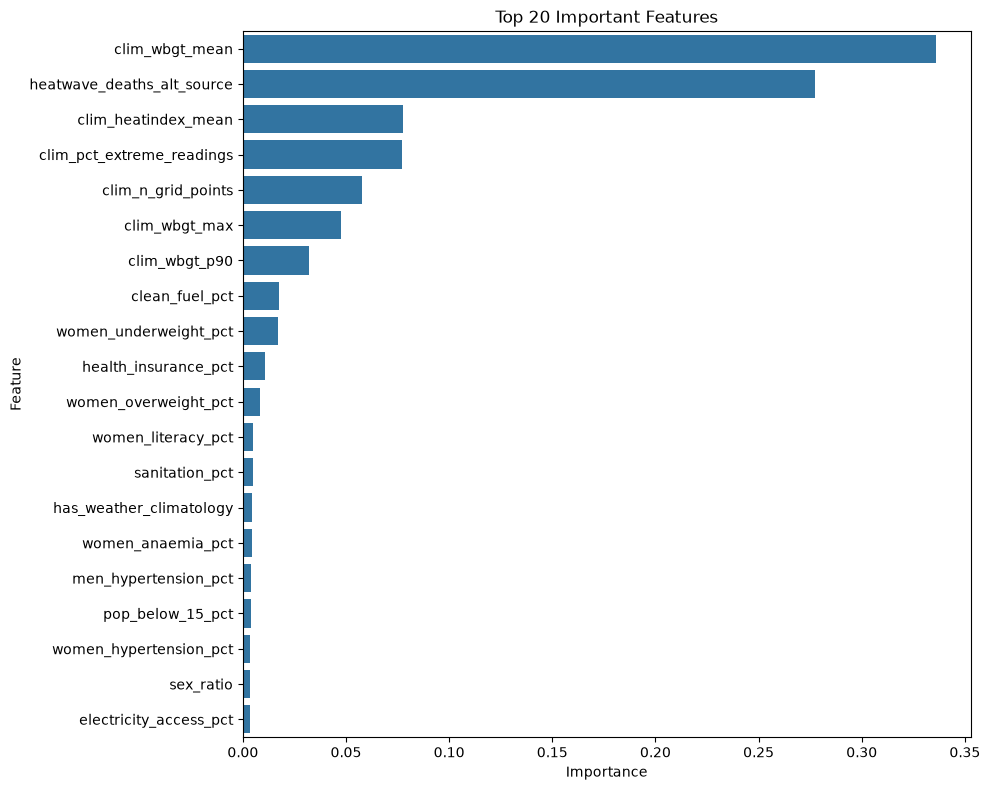

In [21]:

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(20))

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")

plt.tight_layout()

plt.show()

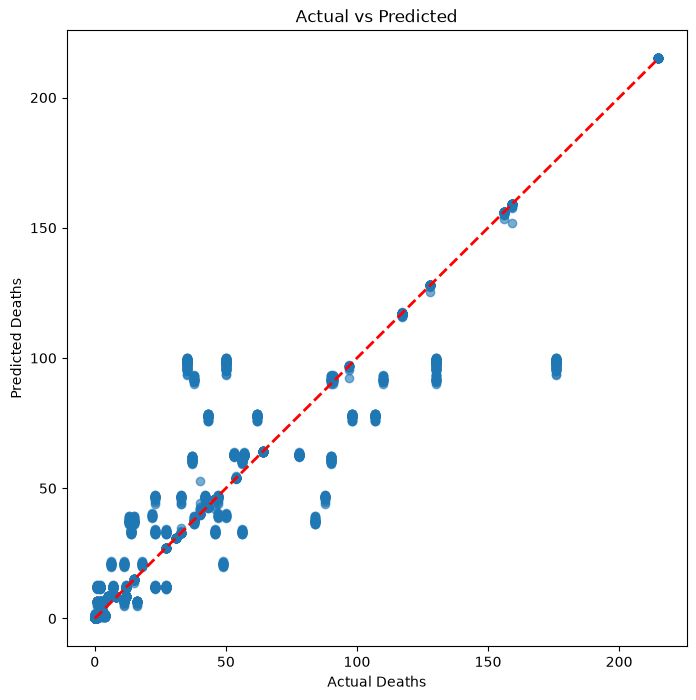

In [22]:
# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

pred = best_model.predict(X)

plt.figure(figsize=(8,8))

plt.scatter(
    y,
    pred,
    alpha=0.6
)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Deaths")
plt.ylabel("Predicted Deaths")

plt.title("Actual vs Predicted")

plt.show()

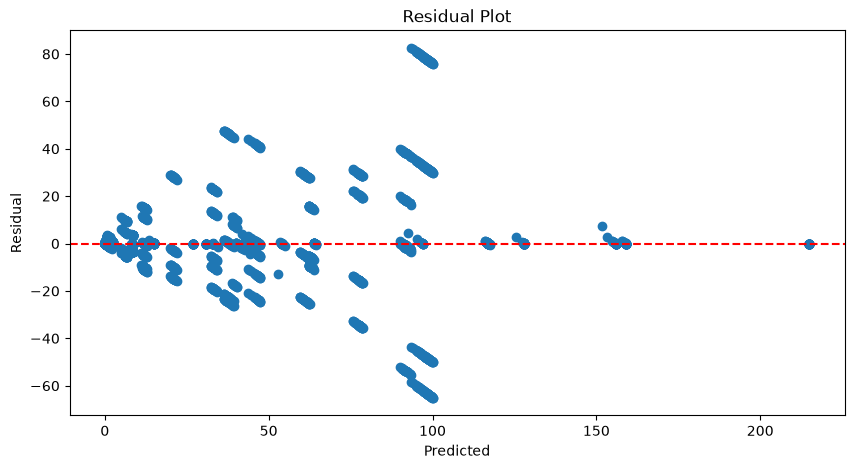

In [23]:
# ============================================================
# RESIDUAL ANALYSIS
# ============================================================

residuals = y - pred

plt.figure(figsize=(10,5))

plt.scatter(pred, residuals)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [25]:
# ============================================================
# SAVE MODEL
# ============================================================
import joblib
joblib.dump(best_model, "best_heat_risk_model.pkl")

joblib.dump(imputer, "imputer.pkl")

joblib.dump(label_encoders, "label_encoders.pkl")

joblib.dump(list(X.columns), "feature_columns.pkl")

print("All Files Saved Successfully!")

All Files Saved Successfully!


In [26]:
# ============================================================
# LOAD MODEL
# ============================================================

model = joblib.load("best_heat_risk_model.pkl")

print(model)

RandomForestRegressor(max_depth=12, n_estimators=300, n_jobs=-1,
                      random_state=42)


In [27]:
# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_heat_risk(new_data):

    model = joblib.load("best_heat_risk_model.pkl")

    imputer = joblib.load("imputer.pkl")

    columns = joblib.load("feature_columns.pkl")

    new_data = new_data[columns]

    new_data = pd.DataFrame(
        imputer.transform(new_data),
        columns=columns
    )

    prediction = model.predict(new_data)

    return prediction

In [28]:
# ============================================================
# EXAMPLE
# ============================================================

sample = X.iloc[:5]

prediction = predict_heat_risk(sample)

result = pd.DataFrame({

    "Actual": y.iloc[:5].values,
    "Predicted": prediction

})

display(result)

,Actual,Predicted
0,0.0,0.013206
1,0.0,0.013206
2,0.0,0.013206
3,0.0,0.013206
4,0.0,0.013206


In [29]:
# ============================================================
# SAVE PREDICTIONS
# ============================================================

predictions = best_model.predict(X)

output = df.copy()

output["Predicted_Deaths"] = predictions

output.to_csv(
    "Predicted_Heat_Mortality.csv",
    index=False
)

print("Prediction File Saved Successfully!")

Prediction File Saved Successfully!
